# Notebook 04 — Model Building

## Random Forest Baseline for Network Intrusion Detection

This notebook builds and evaluates a baseline **Random Forest Classifier** using the 12 features selected in Notebook 03.

### Objective

The main objectives of this notebook are to:

1. Load the feature-selected training and testing datasets.
2. Verify the consistency of the selected features and target labels.
3. Train a baseline Random Forest classification model.
4. Evaluate the model on the unseen test dataset.
5. Calculate Accuracy, Precision, Recall, F1-score, and Macro F1-score.
6. Generate a classification report and confusion matrix.
7. Analyze Random Forest feature importance.
8. Save the trained baseline model and evaluation results for later comparison.

### Input

The model uses the outputs generated by **Notebook 03 — Feature Selection**:

- `X_train_selected.csv`
- `X_test_selected.csv`
- `y_train_selected.csv`
- `y_test_selected.csv`

### Model

**Random Forest Classifier**

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve classification performance and robustness.

### Important Methodological Principle

The model is trained only on the training dataset and evaluated on the held-out test dataset.

No test labels or test observations are used during model training.

## 1. Import Required Libraries

The following Python libraries are used for data loading, model training, evaluation, visualization, timing, and saving the trained model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Feature-Selected Datasets

The training and testing datasets generated in Notebook 03 are loaded from the `data/processed/` directory.

The feature-selected datasets contain **12 final features** chosen using the feature-selection pipeline.

In [2]:
X_train = pd.read_csv("../data/processed/X_train_selected.csv")
X_test = pd.read_csv("../data/processed/X_test_selected.csv")

y_train = pd.read_csv("../data/processed/y_train_selected.csv")
y_test = pd.read_csv("../data/processed/y_test_selected.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [3]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nTraining features:")
print(X_train.columns.tolist())

print("\nTesting features:")
print(X_test.columns.tolist())

X_train shape: (894944, 12)
X_test shape : (223737, 12)
y_train shape: (894944, 1)
y_test shape : (223737, 1)

Training features:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Mean', 'Bwd Packet Length Min', 'Bwd Packets/s', 'PSH Flag Count', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'min_seg_size_forward']

Testing features:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Mean', 'Bwd Packet Length Min', 'Bwd Packets/s', 'PSH Flag Count', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'min_seg_size_forward']


## 3. Verify Feature and Target Consistency

Before training the model, the training and testing datasets are checked to ensure that:

- The training and testing feature sets contain the same 12 features.
- The feature order is identical between training and testing data.
- The number of feature rows matches the number of target labels.
- The target column is correctly identified.

In [4]:
# Check feature consistency
feature_consistency = X_train.columns.tolist() == X_test.columns.tolist()

# Check row consistency
train_row_match = len(X_train) == len(y_train)
test_row_match = len(X_test) == len(y_test)

# Display target column
target_column = y_train.columns[0]

print("Feature consistency:", feature_consistency)
print("Training rows match target:", train_row_match)
print("Testing rows match target:", test_row_match)
print("Target column:", target_column)

print("\nSelected features:")
for i, feature in enumerate(X_train.columns, start=1):
    print(f"{i}. {feature}")

Feature consistency: True
Training rows match target: True
Testing rows match target: True
Target column: Target_Encoded

Selected features:
1. Destination Port
2. Flow Duration
3. Total Fwd Packets
4. Total Length of Fwd Packets
5. Total Length of Bwd Packets
6. Fwd Packet Length Mean
7. Bwd Packet Length Min
8. Bwd Packets/s
9. PSH Flag Count
10. Init_Win_bytes_forward
11. Init_Win_bytes_backward
12. min_seg_size_forward


## 4. Analyze Target Class Distribution

Before training the model, the distribution of the target classes is examined in both the training and testing datasets.

The stratified train-test split performed during preprocessing preserved the class proportions between the two datasets. This check confirms that the target labels are correctly loaded and that all four encoded classes are present.

In [5]:
# Extract target values
y_train_values = y_train[target_column]
y_test_values = y_test[target_column]

# Calculate class distributions
train_distribution = y_train_values.value_counts().sort_index()
test_distribution = y_test_values.value_counts().sort_index()

train_percentage = y_train_values.value_counts(normalize=True).sort_index() * 100
test_percentage = y_test_values.value_counts(normalize=True).sort_index() * 100

# Create comparison table
class_distribution = pd.DataFrame({
    "Train Count": train_distribution,
    "Train Percentage": train_percentage.round(2),
    "Test Count": test_distribution,
    "Test Percentage": test_percentage.round(2)
})

print("Target Class Distribution:")
display(class_distribution)

Target Class Distribution:


,Train Count,Train Percentage,Test Count,Test Percentage
Target_Encoded,,,,
0,718314,80.26,179579,80.26
1,1562,0.17,391,0.17
2,102413,11.44,25603,11.44
3,72655,8.12,18164,8.12


## 5. Visualize Target Class Distribution

The target-class distribution is visualized to clearly show the class imbalance present in the network intrusion detection dataset.

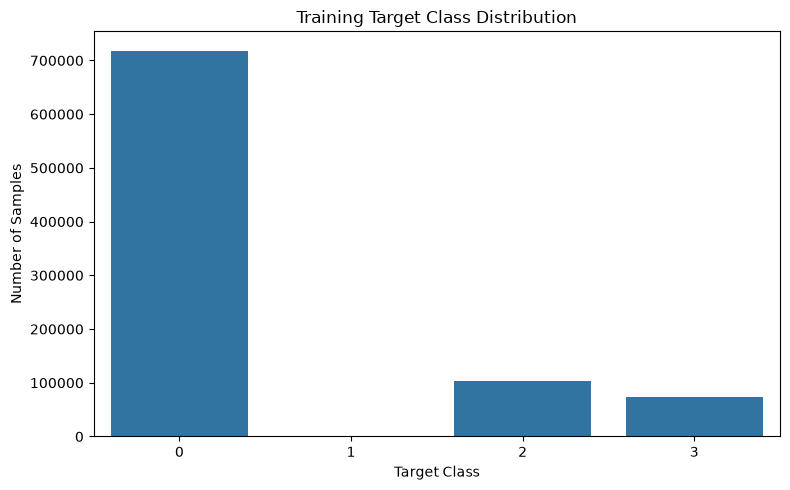

In [6]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x=y_train_values,
    order=sorted(y_train_values.unique())
)

plt.title("Training Target Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

## 6. Define the Baseline Random Forest Classifier

A Random Forest Classifier is used as the baseline machine learning model.

Random Forest combines multiple decision trees and uses ensemble learning to improve prediction stability and reduce the risk of relying on a single decision tree.

The baseline configuration uses:

- 100 decision trees
- `class_weight="balanced_subsample"` to account for class imbalance
- All available selected features at each split
- Parallel processing using all available CPU cores
- Fixed random state for reproducibility

This model serves as the baseline against which the later hyperparameter-tuned model can be compared.

In [7]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

print("Random Forest baseline model initialized successfully.")
print(rf_baseline)

Random Forest baseline model initialized successfully.
RandomForestClassifier(class_weight='balanced_subsample', n_jobs=-1,
                       random_state=42)


## 7. Train the Baseline Random Forest Model

The baseline Random Forest model is trained using only the training dataset.

The test dataset remains completely unseen during model fitting. Training time is recorded to provide a computational-performance reference for later model comparisons.

In [8]:
print("Starting Random Forest training...")

start_time = time.time()

rf_baseline.fit(X_train, y_train_values)

training_time = time.time() - start_time

print(f"Training completed successfully.")
print(f"Training time: {training_time:.2f} seconds")

Starting Random Forest training...
Training completed successfully.
Training time: 35.36 seconds


## 8. Generate Test-Set Predictions

The trained Random Forest model is used to predict the target classes of the unseen test dataset.

The test dataset was not used during model training. Therefore, the resulting predictions provide an unbiased evaluation of the baseline model's performance on unseen data.

In [9]:
print("Generating predictions on the test dataset...")

prediction_start_time = time.time()

y_pred = rf_baseline.predict(X_test)

prediction_time = time.time() - prediction_start_time

print("Test predictions generated successfully.")
print(f"Prediction time: {prediction_time:.2f} seconds")
print(f"Number of predictions: {len(y_pred)}")

Generating predictions on the test dataset...
Test predictions generated successfully.
Prediction time: 0.39 seconds
Number of predictions: 223737


## 9. Evaluate Baseline Model Performance

The baseline Random Forest model is evaluated using the following classification metrics:

- **Accuracy** — proportion of correctly classified samples.
- **Precision** — proportion of predicted positive/class instances that are correct.
- **Recall** — proportion of actual class instances correctly identified.
- **F1-score** — harmonic mean of precision and recall.
- **Macro F1-score** — average F1-score across all classes, giving equal importance to each class.

Because the dataset is highly imbalanced, **Macro F1-score** is particularly important for assessing whether the model performs well across minority classes rather than primarily on the majority class.

In [10]:
accuracy = accuracy_score(y_test_values, y_pred)

precision = precision_score(
    y_test_values,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test_values,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test_values,
    y_pred,
    average="weighted",
    zero_division=0
)

macro_f1 = f1_score(
    y_test_values,
    y_pred,
    average="macro",
    zero_division=0
)

baseline_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-score",
        "Macro F1-score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        macro_f1
    ]
})

display(baseline_results)

,Metric,Score
0,Accuracy,0.999057
1,Weighted Precision,0.999252
2,Weighted Recall,0.999057
3,Weighted F1-score,0.999122
4,Macro F1-score,0.946513


## 10. Classification Report

The classification report provides class-wise Precision, Recall, and F1-score for all target classes.

This analysis is important because overall accuracy and weighted metrics can be strongly influenced by the majority class. Class-wise metrics provide a clearer view of how effectively the model detects each network traffic category.

In [11]:
report = classification_report(
    y_test_values,
    y_pred,
    zero_division=0
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    179579
           1       0.68      0.93      0.79       391
           2       1.00      1.00      1.00     25603
           3       1.00      1.00      1.00     18164

    accuracy                           1.00    223737
   macro avg       0.92      0.98      0.95    223737
weighted avg       1.00      1.00      1.00    223737



## 11. Confusion Matrix

A confusion matrix is used to examine the detailed classification behavior of the baseline Random Forest model.

Each row represents the actual class and each column represents the predicted class. Correct predictions appear along the diagonal, while off-diagonal values represent misclassifications.

This visualization helps identify which network traffic classes are being confused by the model.

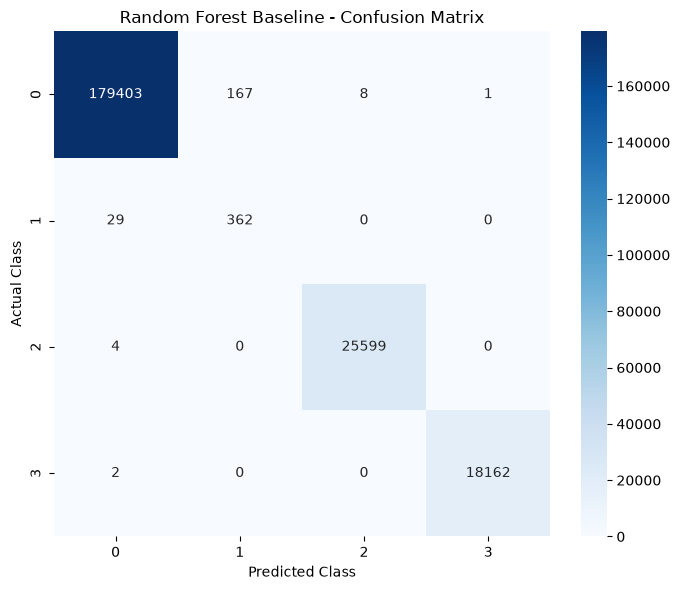

In [12]:
cm = confusion_matrix(y_test_values, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_test_values.unique()),
    yticklabels=sorted(y_test_values.unique())
)

plt.title("Random Forest Baseline - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

## 12. Analyze Confusion Matrix Results

The confusion matrix shows that the majority of predictions are concentrated along the diagonal, indicating correct classification.

The baseline Random Forest correctly classified:

- **179,403** samples of Class 0
- **362** samples of Class 1
- **25,599** samples of Class 2
- **18,162** samples of Class 3

The largest classification errors occur between Classes 0 and 1:

- 167 samples from actual Class 0 were predicted as Class 1.
- 29 samples from actual Class 1 were predicted as Class 0.

Classes 2 and 3 show very few misclassifications.

These results demonstrate strong overall classification performance while also highlighting the difficulty of correctly identifying the minority Class 1.

## 13. Random Forest Feature Importance

Random Forest provides an importance score for each input feature based on its contribution to reducing impurity across the decision trees.

The feature importance values are analyzed to understand which of the 12 selected network traffic features contribute most strongly to the baseline model.

In [13]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_baseline.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.index = feature_importance.index + 1

display(feature_importance)

,Feature,Importance
1,Fwd Packet Length Mean,0.165440
2,Destination Port,0.154439
3,Total Length of Fwd Packets,0.127467
4,Flow Duration,0.081227
5,Init_Win_bytes_forward,0.079458
6,Init_Win_bytes_backward,0.073132
7,Total Length of Bwd Packets,0.060432
8,Bwd Packets/s,0.060364
9,Total Fwd Packets,0.052503
10,Bwd Packet Length Min,0.050990


## 14. Visualize Feature Importance

The feature importance scores are visualized to provide a clear comparison of the contribution of the 12 selected network traffic features to the Random Forest model.

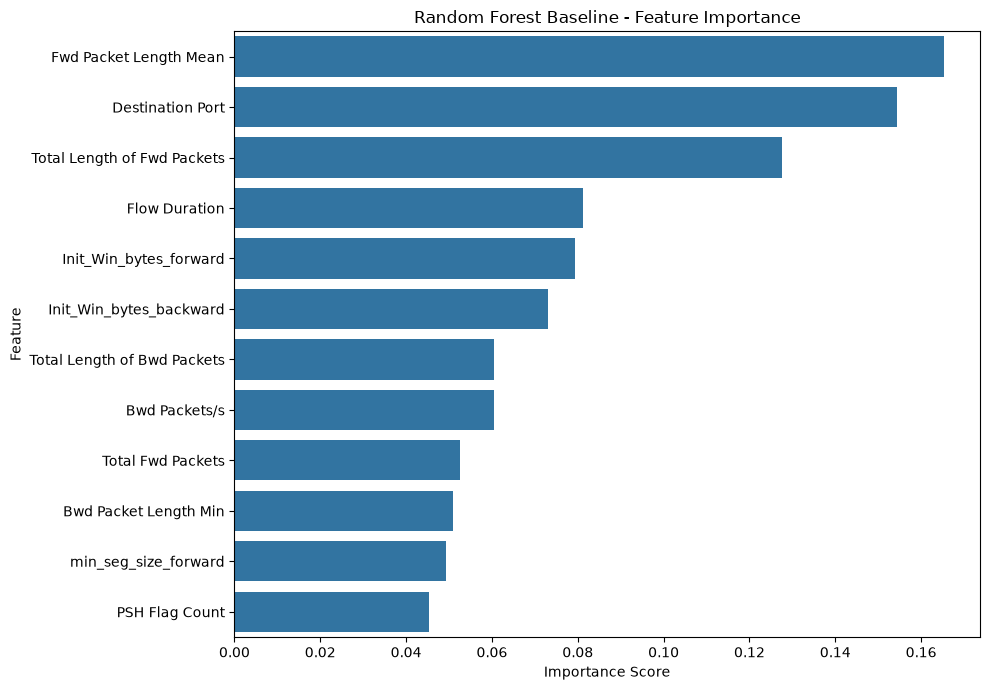

In [14]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Baseline - Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 15. Feature Importance Summary

The feature-importance analysis shows that the Random Forest model relies most strongly on packet-length characteristics, destination port information, flow duration, and TCP window-related features.

The most influential feature is **Fwd Packet Length Mean**, followed by **Destination Port** and **Total Length of Fwd Packets**.

The importance scores provide interpretability for the baseline model and help identify which network traffic characteristics contribute most to intrusion classification.

## 16. Save the Baseline Model

The trained Random Forest baseline model is saved to the `models/` directory.

Saving the model allows it to be reused later without retraining and provides a baseline model for comparison with the hyperparameter-tuned model developed in Notebook 05.

In [15]:
model_path = "../models/random_forest_baseline.pkl"

joblib.dump(rf_baseline, model_path)

print(f"Baseline model saved successfully to: {model_path}")

Baseline model saved successfully to: ../models/random_forest_baseline.pkl


## 17. Save Baseline Evaluation Results

The baseline model's evaluation metrics are saved as a CSV file for later comparison with the hyperparameter-tuned Random Forest model.

In [16]:
results_path = "../data/processed/model_building_baseline_results.csv"

baseline_results.to_csv(results_path, index=False)

print(f"Baseline evaluation results saved successfully to: {results_path}")

Baseline evaluation results saved successfully to: ../data/processed/model_building_baseline_results.csv


## 18. Final Model Validation

The final validation checks confirm that:

- The baseline model was trained successfully.
- Predictions were generated for all test samples.
- The number of predictions matches the number of test observations.
- All four target classes are represented.
- The trained model contains the expected 12 input features.
- The evaluation results were generated successfully.

In [17]:
print("Model validation checks")
print("-" * 50)

print("Model trained:", hasattr(rf_baseline, "estimators_"))
print("Number of trees:", len(rf_baseline.estimators_))
print("Number of model features:", rf_baseline.n_features_in_)
print("Expected features:", X_train.shape[1])
print("Prediction count:", len(y_pred))
print("Expected test samples:", len(y_test_values))
print("Prediction count matches test set:", len(y_pred) == len(y_test_values))
print("Target classes:", sorted(y_test_values.unique()))
print("Results saved:", results_path)
print("Model saved:", model_path)

Model validation checks
--------------------------------------------------
Model trained: True
Number of trees: 100
Number of model features: 12
Expected features: 12
Prediction count: 223737
Expected test samples: 223737
Prediction count matches test set: True
Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Results saved: ../data/processed/model_building_baseline_results.csv
Model saved: ../models/random_forest_baseline.pkl


# 🏆 Notebook 04 — Model Building: Final Summary

## 🎯 Objective

This notebook developed and evaluated a **baseline Random Forest Classifier** for network intrusion detection using the **12 features selected in Notebook 03**.

The model was trained exclusively on the training dataset and evaluated on the previously unseen test dataset to maintain a clear separation between model training and final evaluation.

---

## 🔄 Complete Model-Building Pipeline

```mermaid
flowchart TD
    A[Notebook 03<br/>Feature Selection] --> B[12 Selected Features]

    B --> C[X_train_selected<br/>894,944 × 12]
    B --> D[X_test_selected<br/>223,737 × 12]

    C --> E[Random Forest Baseline]
    E --> F[100 Decision Trees]

    F --> G[Model Training<br/>35.36 seconds]

    G --> H[Test Prediction]
    D --> H

    H --> I[Classification Metrics]
    I --> J[Accuracy]
    I --> K[Precision]
    I --> L[Recall]
    I --> M[F1-score]
    I --> N[Macro F1-score]

    H --> O[Classification Report]
    H --> P[Confusion Matrix]
    E --> Q[Feature Importance]

    J --> R[Baseline Evaluation]
    N --> R
    P --> R
    Q --> R

    R --> S[Save Baseline Model]
    R --> T[Save Evaluation Results]
```

---

## 📊 Dataset Used

| Dataset      | Samples | Features |
| ------------ | ------: | -------: |
| Training Set | 894,944 |       12 |
| Testing Set  | 223,737 |       12 |

The model used the following **12 features**:

|  # | Selected Feature            |
| -: | --------------------------- |
|  1 | Destination Port            |
|  2 | Flow Duration               |
|  3 | Total Fwd Packets           |
|  4 | Total Length of Fwd Packets |
|  5 | Total Length of Bwd Packets |
|  6 | Fwd Packet Length Mean      |
|  7 | Bwd Packet Length Min       |
|  8 | Bwd Packets/s               |
|  9 | PSH Flag Count              |
| 10 | Init_Win_bytes_forward      |
| 11 | Init_Win_bytes_backward     |
| 12 | min_seg_size_forward        |

---

## 🌲 Baseline Random Forest Configuration

| Parameter           | Value                    |
| ------------------- | ------------------------ |
| Algorithm           | Random Forest Classifier |
| Number of Trees     | 100                      |
| Class Weight        | `balanced_subsample`     |
| Parallel Processing | `n_jobs=-1`              |
| Random State        | 42                       |
| Input Features      | 12                       |
| Training Samples    | 894,944                  |

The `balanced_subsample` class-weight strategy was used because the dataset contains significant class imbalance.

---

## ⏱️ Training Performance

The baseline Random Forest was successfully trained in:

### **35.36 seconds**

This training time provides a computational reference point for comparison with the hyperparameter-tuned model developed in Notebook 05.

---

# 📈 Baseline Test Performance

The trained model was evaluated on **223,737 unseen test samples**.

| Metric                 |        Score |
| ---------------------- | -----------: |
| **Accuracy**           | **0.999057** |
| **Weighted Precision** | **0.999252** |
| **Weighted Recall**    | **0.999057** |
| **Weighted F1-score**  | **0.999122** |
| **Macro F1-score**     | **0.946513** |

### ⭐ Key Result

The baseline Random Forest achieved an accuracy of approximately **99.91%** on the held-out test dataset.

The **Macro F1-score of 0.946513** provides a more informative measure of performance across all four classes because it gives equal importance to each class despite the strong class imbalance.

---

## 🧾 Class-Wise Classification Performance

|                Class | Precision |   Recall | F1-score |     Support |
| -------------------: | --------: | -------: | -------: | ----------: |
|                **0** |      1.00 |     1.00 |     1.00 |     179,579 |
|                **1** |      0.68 |     0.93 |     0.79 |         391 |
|                **2** |      1.00 |     1.00 |     1.00 |      25,603 |
|                **3** |      1.00 |     1.00 |     1.00 |      18,164 |
|    **Macro Average** |  **0.92** | **0.98** | **0.95** | **223,737** |
| **Weighted Average** |  **1.00** | **1.00** | **1.00** | **223,737** |

### 🔎 Observation

The model performs extremely strongly on Classes **0, 2, and 3**.

Class **1** has only **391 test samples**, making it the minority class. Its lower precision and F1-score are the main reason the Macro F1-score is lower than the weighted F1-score.

---

# 🔥 Confusion Matrix Analysis

The confusion matrix contained the following results:

| Actual \ Predicted |     Class 0 | Class 1 |    Class 2 |    Class 3 |
| ------------------ | ----------: | ------: | ---------: | ---------: |
| **Class 0**        | **179,403** |     167 |          8 |          1 |
| **Class 1**        |          29 | **362** |          0 |          0 |
| **Class 2**        |           4 |       0 | **25,599** |          0 |
| **Class 3**        |           2 |       0 |          0 | **18,162** |

### Key observations

* Class 0 has **179,403 correct predictions**.
* Class 1 has **362 correct predictions** out of 391.
* Class 2 has **25,599 correct predictions**.
* Class 3 has **18,162 correct predictions**.
* The largest source of misclassification is between **Class 0 and Class 1**.
* Classes 2 and 3 are classified with almost no confusion.

The strong diagonal dominance demonstrates the high predictive performance of the baseline Random Forest.

---

# ⭐ Feature Importance Analysis

The Random Forest identified the following feature importance ranking:

| Rank | Feature                         |   Importance |
| ---: | ------------------------------- | -----------: |
|    1 | **Fwd Packet Length Mean**      | **0.165440** |
|    2 | **Destination Port**            | **0.154439** |
|    3 | **Total Length of Fwd Packets** | **0.127467** |
|    4 | Flow Duration                   |     0.081227 |
|    5 | Init_Win_bytes_forward          |     0.079458 |
|    6 | Init_Win_bytes_backward         |     0.073132 |
|    7 | Total Length of Bwd Packets     |     0.060432 |
|    8 | Bwd Packets/s                   |     0.060364 |
|    9 | Total Fwd Packets               |     0.052503 |
|   10 | Bwd Packet Length Min           |     0.050990 |
|   11 | min_seg_size_forward            |     0.049228 |
|   12 | PSH Flag Count                  |     0.045319 |

### 🧠 Important Finding

The three most influential features were:

**Fwd Packet Length Mean → Destination Port → Total Length of Fwd Packets**

These features collectively account for approximately **44.72%** of the Random Forest's total feature importance.

This demonstrates that packet-length characteristics and destination-port information play an important role in the baseline intrusion-classification model.

---

# 🔐 Data Leakage Prevention

```mermaid
flowchart LR
    A[Training Data] --> B[Train Random Forest]
    B --> C[Trained Model]

    D[Held-Out Test Data] --> E[Test Prediction]
    C --> E

    E --> F[Final Evaluation]

    G[Test Labels] --> F

    B -. No Test Data Used .-> D
```

The test dataset was not used during model fitting.

Therefore:

* Model parameters were learned from training data only.
* Test data remained unseen during training.
* Test predictions were generated only after model training.
* Final performance metrics were calculated using the held-out test set.

This separation reduces the risk of data leakage during model evaluation.

---

# ✅ Final Validation

| Validation Check                  | Result         |
| --------------------------------- | -------------- |
| Model trained successfully        | ✅              |
| Number of trees                   | **100**        |
| Model input features              | **12**         |
| Expected input features           | **12**         |
| Test predictions generated        | **223,737**    |
| Expected test samples             | **223,737**    |
| Prediction count matches test set | ✅              |
| Target classes detected           | **0, 1, 2, 3** |
| Baseline model saved              | ✅              |
| Evaluation results saved          | ✅              |

---

# 📁 Output Files

The following outputs were generated:

```text
models/
└── random_forest_baseline.pkl

data/
└── processed/
    └── model_building_baseline_results.csv
```

### Saved Model

`random_forest_baseline.pkl`

Contains the trained 100-tree Random Forest baseline model.

### Saved Results

`model_building_baseline_results.csv`

Contains the baseline evaluation metrics for later comparison.

---

# 🏁 Final Conclusion

The baseline Random Forest model successfully classified the four network traffic classes using the **12 features selected in Notebook 03**.

The model achieved:

> **99.9057% Accuracy**

and:

> **0.946513 Macro F1-score**

on **223,737 unseen test samples**.

The results demonstrate that the selected features contain strong predictive information for network intrusion detection. However, the lower performance for the minority **Class 1** highlights the importance of evaluating class-wise metrics rather than relying only on overall accuracy.

The baseline model and its evaluation results are now saved and can be used as the reference point for **hyperparameter tuning in Notebook 05**.

---

# 🏆 Final Result Flow

```text
37 Preprocessed Features
        ↓
Feature Selection
        ↓
12 Final Features
        ↓
894,944 Training Samples
        ↓
Random Forest Baseline
        ↓
100 Trees
        ↓
35.36 Seconds Training
        ↓
223,737 Unseen Test Samples
        ↓
99.9057% Accuracy
        ↓
0.946513 Macro F1
        ↓
Baseline Model Saved
        ↓
🚀 Notebook 05 — Hyperparameter Tuning
```

## 🚀 Next Stage

**Notebook 05 — Hyperparameter Tuning**

The baseline Random Forest developed in this notebook will serve as the reference model for systematic hyperparameter optimization and comparison.
